# Calibrating S_t

In [18]:
import numpy as np
import matplotlib.pyplot as plt
def S_t(t, onset=0.30, offset=2, duration=-1, amplitude=0.1, d=0.35):
    if duration < 0:
        duration = offset - onset
    S_base = np.where((t >= onset) & (t <= onset + duration), amplitude, 0)
    tail_start = onset + duration
    tail = np.where(
        (t>=tail_start)&(t<=tail_start+d),
        amplitude*np.exp(-3*(t-tail_start)/d),
        0
    )       
    return np.maximum(S_base, tail)

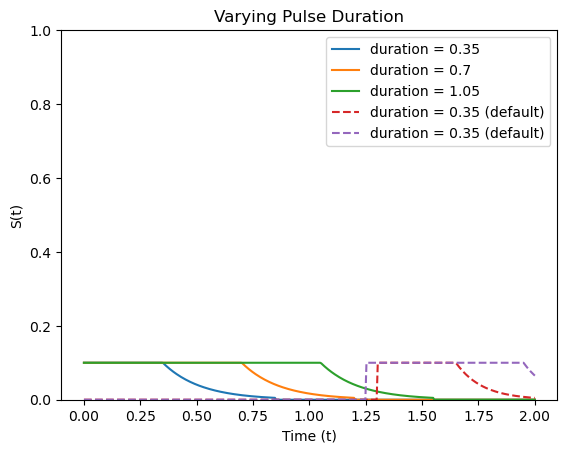

In [19]:
t = np.linspace(0, 2, 400)


plt.figure()
for dur in [0.35, 0.7, 1.05]:
    y = S_t(t, onset=0.0, duration=dur, amplitude=0.1, d=0.5)
    plt.plot(t, y, label=f'duration = {dur}')
y = S_t(t, onset=1.3, duration=0.35, amplitude=0.1, d=0.35)
plt.plot(t, y, label='duration = 0.35 (default)', linestyle='--')
y = S_t(t, onset=1.25, duration=0.7, amplitude=0.1, d=0.35)
plt.plot(t, y, label='duration = 0.35 (default)', linestyle='--')
plt.title('Varying Pulse Duration')
plt.xlabel('Time (t)')
plt.ylabel('S(t)')
plt.legend()
plt.ylim(0,1)
plt.show()

